In [1]:
# CELL 1 — project setup + imports (single source of truth)

import sys
from pathlib import Path
import pandas as pd
import numpy as np

# ---- EDIT THESE 3 PATHS ONCE ----
CODE_ROOT = Path("/Users/benjaminsalop/Desktop/Oxford/Research/edca/code")      # parent of `earlystruct`
DATA_DIR  = Path("/Users/benjaminsalop/Desktop/Oxford/Research/edca/csvs")      # csv folder
CONTROL_FILE = Path("/Users/benjaminsalop/Desktop/Oxford/Research/edca/control_file/control_file.txt")

systems_catalog = pd.read_csv("/Users/benjaminsalop/Desktop/Oxford/Research/edca/csvs/systems_catalog.csv")
bar_spacing_raw = pd.read_csv("/Users/benjaminsalop/Desktop/Oxford/Research/edca/csvs/bar_spacing.csv")

for p in [CODE_ROOT, DATA_DIR, CONTROL_FILE]:
    if not p.exists():
        raise FileNotFoundError(f"Missing path: {p}")

if str(CODE_ROOT) not in sys.path:
    sys.path.insert(0, str(CODE_ROOT))

# earlystruct imports (assumes your package structure is correct)
from earlystruct.core.control import parse_control
from earlystruct import cli
from earlystruct.core import reporting
from earlystruct.CodeChecks import continuouslab as continuouslab_mod

# plotting
import matplotlib.pyplot as plt

print("✅ Imports OK")
print("CODE_ROOT:", CODE_ROOT)
print("DATA_DIR:", DATA_DIR)
print("CONTROL_FILE:", CONTROL_FILE)


✅ Imports OK
CODE_ROOT: /Users/benjaminsalop/Desktop/Oxford/Research/edca/code
DATA_DIR: /Users/benjaminsalop/Desktop/Oxford/Research/edca/csvs
CONTROL_FILE: /Users/benjaminsalop/Desktop/Oxford/Research/edca/control_file/control_file.txt


In [2]:
# CELL 2 — load bar spacing + run evaluation + parse control

def load_bar_spacing(data_dir: Path) -> pd.DataFrame | None:
    """Load bar_spacing.csv if present; return None if missing/unreadable."""
    bs_path = data_dir / "bar_spacing.csv"
    if not bs_path.exists():
        print(f"⚠️ bar_spacing.csv not found at {bs_path}")
        return None
    try:
        df = pd.read_csv(bs_path)
        if df.empty:
            print(f"⚠️ bar_spacing.csv is empty: {bs_path}")
            return None
        return df
    except Exception as e:
        print(f"⚠️ Failed to read {bs_path}: {e}")
        return None

bar_spacing_raw = load_bar_spacing(DATA_DIR)
continuouslab_mod.bar_spacing = bar_spacing_raw  # optional convenience, but we also pass explicitly later

# Run the main eval
df, ranked, pareto, saved = cli.evaluate(
    data_dir=DATA_DIR,
    spans_str=None,
    export_dir=None,
    control_file=str(CONTROL_FILE),
)

# Parse control file once (avoid the repeated diagnostics cell)
ctl = parse_control(str(CONTROL_FILE))

project = {}
if isinstance(saved, dict):
    project = saved.get("project", {}) or {}

print("✅ Evaluation complete")
print("df shape:", df.shape)
print("ranked shape:", None if not isinstance(ranked, pd.DataFrame) else ranked.shape)
print("ctl keys:", list(ctl.keys())[:12], "...")


✅ Evaluation complete
df shape: (308, 43)
ranked shape: (97, 43)
ctl keys: ['USE_CSV', 'DATA_DIR', 'PROJECT_NAME', 'LOCATION', 'UNIT', 'FLOOR_AREA_PER_FLOOR', 'FLOOR_TO_FLOOR', 'NUM_FLOORS', 'IDEAL_COLUMN_SPACING', 'PLATE_LENGTH', 'PLATE_WIDTH', 'DEPTH_LIMIT_ENABLED'] ...


In [3]:
# CELL 3 — tidy helpers (feasible parsing, numeric coercion, units display)

def normalize_feasible(s: pd.Series) -> pd.Series:
    if s.dtype == bool:
        return s.fillna(False)
    s2 = s.astype(str).str.strip().str.upper()
    return s2.map({
        "Y": True, "YES": True, "TRUE": True, "T": True, "1": True,
        "N": False, "NO": False, "FALSE": False, "F": False, "0": False,
    }).fillna(False)

def prepare_results(df_in: pd.DataFrame) -> pd.DataFrame:
    df2 = df_in.copy()

    if "feasible" in df2.columns:
        df2["feasible"] = normalize_feasible(df2["feasible"])
    else:
        df2["feasible"] = False

    for col in ("carbon_per_m2", "cost_per_m2", "cost_total", "carbon_total_kg"):
        if col in df2.columns:
            df2[col] = pd.to_numeric(df2[col], errors="coerce")

    # add typology if your reporting module provides it
    if "typology" not in df2.columns:
        try:
            df2 = reporting.add_typology(df2)
        except Exception:
            pass

    for c in ("type", "system_id", "typology", "category"):
        if c in df2.columns:
            df2[c] = df2[c].astype(str)

    return df2

df_clean = prepare_results(df)

# Optional display-friendly ft columns (only if unit is imperial in ctl)
UNIT = str(ctl.get("UNIT", "metric")).lower()
is_imperial = UNIT.startswith("imp") or ("ft" in UNIT)
FT_PER_M = 3.28084

df_disp = df_clean.copy()
if is_imperial:
    if "span_slab_dir_m" in df_disp.columns:
        df_disp["span_slab_dir_ft"] = df_disp["span_slab_dir_m"] * FT_PER_M
    if "span_beam_dir_m" in df_disp.columns:
        df_disp["span_beam_dir_ft"] = df_disp["span_beam_dir_m"] * FT_PER_M

print("✅ df_clean ready:", df_clean.shape)
print("Imperial display:", is_imperial)


✅ df_clean ready: (308, 44)
Imperial display: False


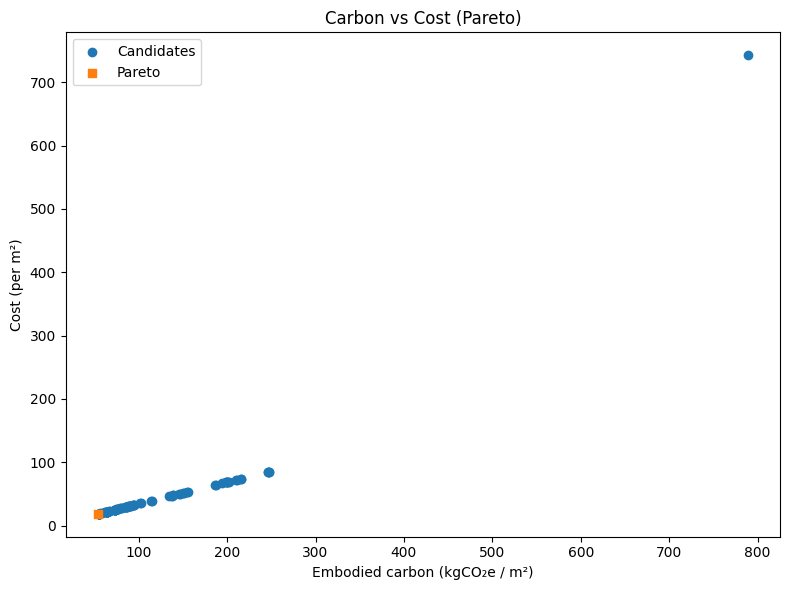

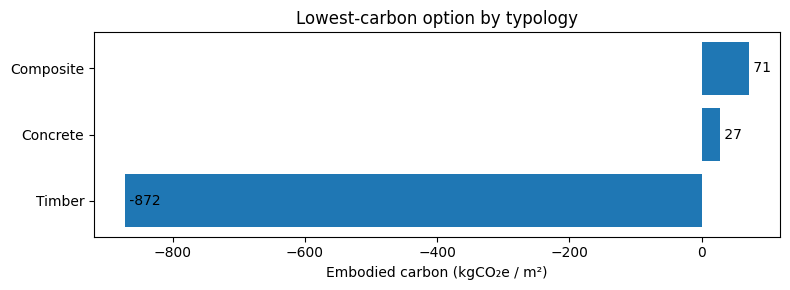

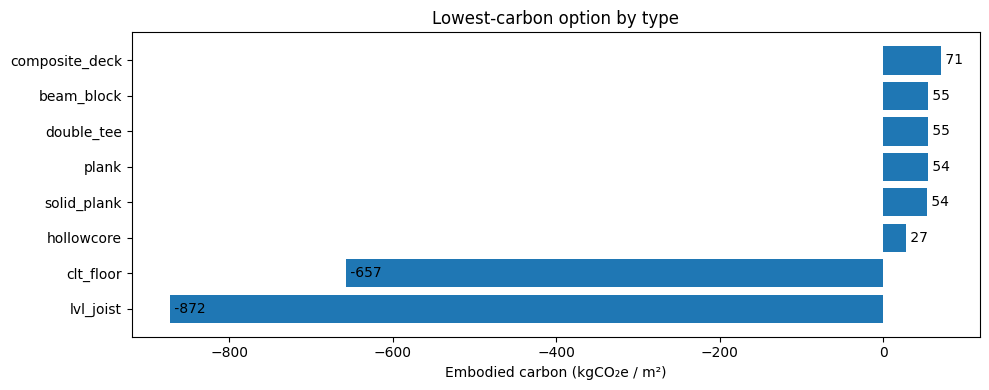

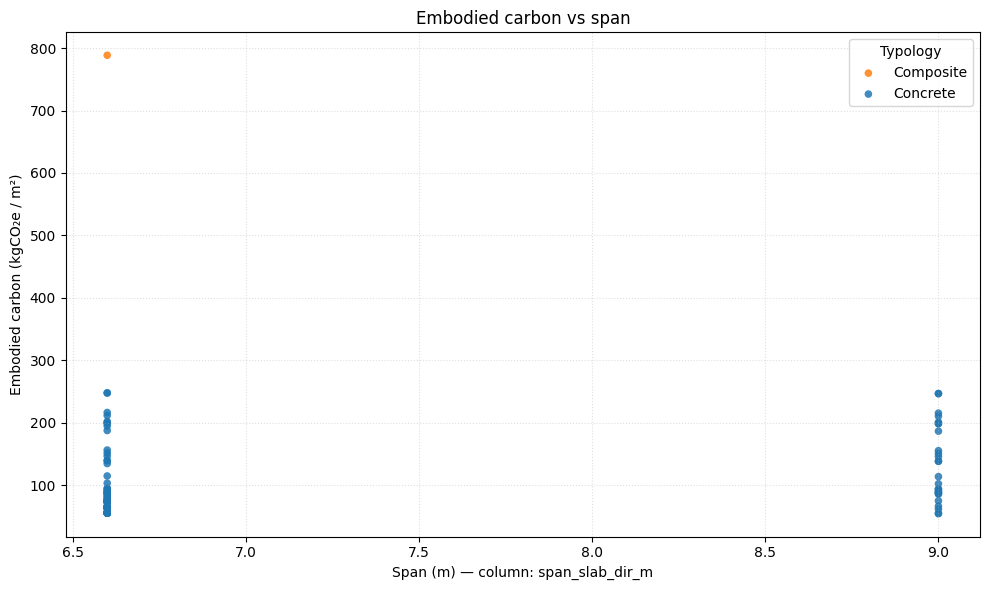

Rows plotted: 7036
Saved: plots/catalog_span_vs_best_carbon.png


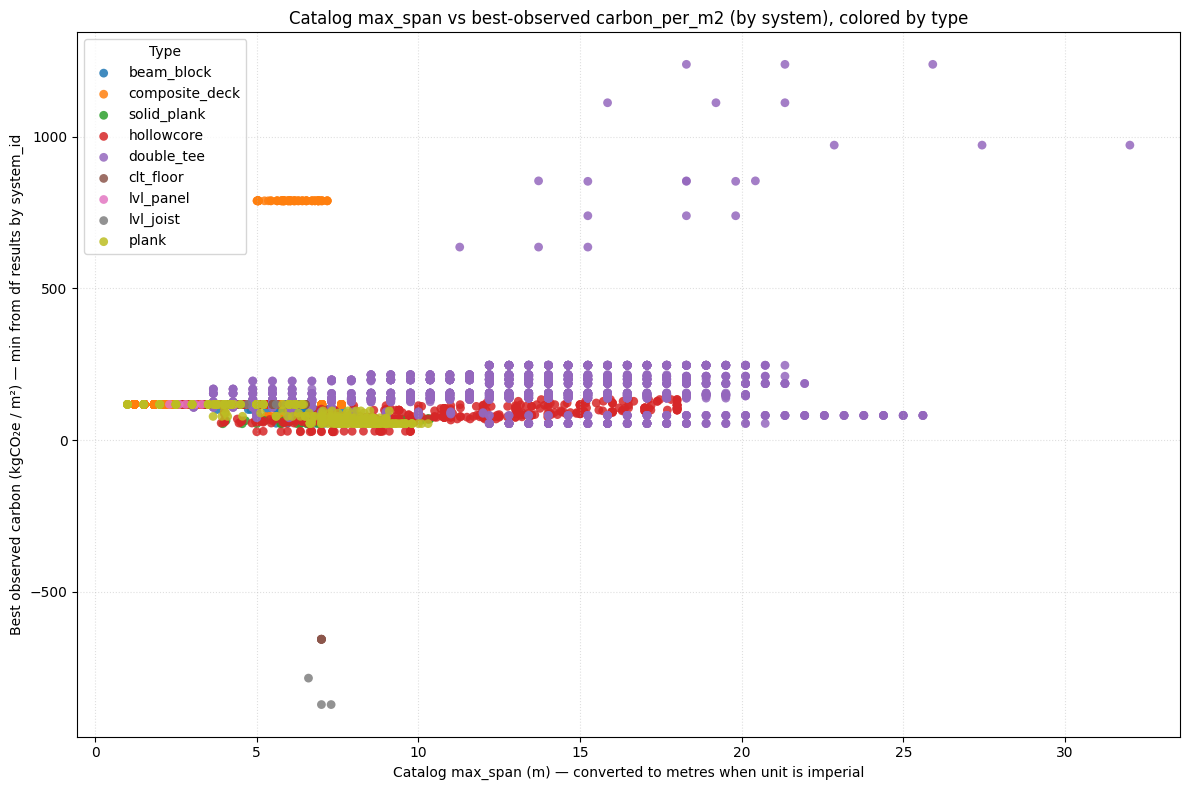

In [4]:
reporting.plot_pareto(df_clean, title="Carbon vs Cost (Pareto)")
plt.show()

reporting.plot_best_typology_carbon(df_clean, title="Lowest-carbon option by typology")
plt.show()

reporting.plot_best_type_carbon(df_clean, title="Lowest-carbon option by type")
plt.show()

reporting.plot_carbon_vs_span(
    df_clean,
    span_col="span_slab_dir_m",
    carbon_col="carbon_per_m2",
    only_feasible=True,
    title="Embodied carbon vs span"
)
plt.show()

# CELL — Catalog max_span vs best-observed carbon_per_m2 (by system), colored by type

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

def _unit_is_imperial(u) -> bool:
    s = str(u).strip().lower()
    return (
        s.startswith("imp")
        or s in {"imperial", "us", "us customary", "usc", "ft", "feet"}
        or "imperial" in s
        or "ft" in s
    )

def plot_catalog_span_vs_best_carbon(
    systems_catalog: pd.DataFrame,
    df_results: pd.DataFrame,
    *,
    only_feasible: bool = False,
    type_col: str | None = None,
    span_col_catalog: str = "max_span",
    unit_col_catalog: str = "unit",
    carbon_col_results: str = "carbon_per_m2",
    system_id_col: str = "system_id",
    figsize=(12, 8),
    title="Catalog max_span vs best-observed carbon_per_m2 (by system), colored by type",
    savepath: str | Path | None = None,
    show_validator: bool = False,
):
    # --- basic checks ---
    if system_id_col not in systems_catalog.columns:
        raise KeyError(f"systems_catalog missing '{system_id_col}'")

    if span_col_catalog not in systems_catalog.columns:
        raise KeyError(f"systems_catalog missing '{span_col_catalog}'")

    if system_id_col not in df_results.columns:
        # case-insensitive rescue
        lower_map = {c.lower(): c for c in df_results.columns}
        if system_id_col in lower_map:
            df_results = df_results.rename(columns={lower_map[system_id_col]: system_id_col})
        else:
            raise KeyError(f"df_results missing '{system_id_col}'")

    # --- choose type column for coloring ---
    if type_col is None:
        if "type" in systems_catalog.columns:
            type_col = "type"
        elif "category" in systems_catalog.columns:
            type_col = "category"
        else:
            type_col = "__type"
            systems_catalog = systems_catalog.copy()
            systems_catalog[type_col] = "Unknown"

    # --- normalize catalog span to metres ---
    feet_to_m = 0.3048
    systems = systems_catalog.copy()
    systems["_max_span_raw"] = pd.to_numeric(systems[span_col_catalog], errors="coerce")

    if unit_col_catalog in systems.columns:
        u = systems[unit_col_catalog]
    else:
        u = pd.Series("metric", index=systems.index)

    systems["_is_imperial"] = u.map(_unit_is_imperial)
    systems["_max_span_m"] = np.where(systems["_is_imperial"], systems["_max_span_raw"] * feet_to_m, systems["_max_span_raw"])

    # --- best-observed carbon per system_id from df_results ---
    D = df_results.copy()
    D["_carbon_num"] = pd.to_numeric(D.get(carbon_col_results), errors="coerce")

    if only_feasible and "feasible" in D.columns:
        # robust truthy mapping
        s = D["feasible"]
        if s.dtype != bool:
            s2 = s.astype(str).str.strip().str.upper()
            D["feasible"] = s2.map({"Y": True,"YES": True,"TRUE": True,"T": True,"1": True,"N": False,"NO": False,"FALSE": False,"F": False,"0": False}).fillna(False)
        D = D[D["feasible"]]

    best_by_system = (
        D.loc[D["_carbon_num"].notna(), [system_id_col, "_carbon_num"]]
        .groupby(system_id_col, as_index=False)["_carbon_num"]
        .min()
        .rename(columns={"_carbon_num": "carbon_best_per_m2"})
    )

    merged = systems.merge(best_by_system, how="left", on=system_id_col)

    # optional fallback so points still appear if some systems never evaluated
    if merged["carbon_best_per_m2"].isna().any():
        fallback = D["_carbon_num"].mean() if D["_carbon_num"].notna().any() else np.nan
        merged["carbon_best_per_m2"] = merged["carbon_best_per_m2"].fillna(fallback)

    plot_df = merged.loc[merged["_max_span_m"].notna() & merged["carbon_best_per_m2"].notna()].copy()
    print("Rows plotted:", len(plot_df))

    # --- optional “suspicious span” validator (prints, does not change plot) ---
    if show_validator:
        soft_caps_m = {
            "hollowcore": 18.0, "double_tee": 30.0, "composite_deck": 15.0,
            "solid_plank": 12.0, "clt_floor": 12.0, "lvl_panel": 15.0,
            "lvl_joist": 12.0, "beam_block": 8.0, "plank": 12.0,
        }
        def _flag(r):
            t = str(r.get(type_col, "")).lower()
            cap = soft_caps_m.get(t)
            return (cap is not None and r["_max_span_m"] > cap) or (r["_max_span_m"] > 40.0)

        flags = plot_df.loc[plot_df.apply(_flag, axis=1)]
        if not flags.empty:
            cols = [system_id_col, type_col, unit_col_catalog, span_col_catalog, "_is_imperial", "_max_span_m"]
            cols = [c for c in cols if c in flags.columns]
            print("\n[validator] Suspicious spans (top 25 by span):")
            display(flags.sort_values("_max_span_m", ascending=False).head(25)[cols])
        else:
            print("\n[validator] No spans exceeded soft caps or 40 m global threshold.")

    # --- plotting (matplotlib only, no seaborn) ---
    types = list(pd.unique(plot_df[type_col].astype(str)))
    default_colors = plt.rcParams.get("axes.prop_cycle").by_key().get("color", ["C0","C1","C2","C3","C4","C5","C6","C7","C8","C9"])
    color_map = {t: default_colors[i % len(default_colors)] for i, t in enumerate(types)}

    fig, ax = plt.subplots(figsize=figsize)
    for t in types:
        sub = plot_df[plot_df[type_col].astype(str) == t]
        ax.scatter(
            sub["_max_span_m"],
            sub["carbon_best_per_m2"],
            s=40,
            alpha=0.85,
            label=t,
            c=color_map[t],
            edgecolors="none",
        )

    ax.set_xlabel("Catalog max_span (m) — converted to metres when unit is imperial")
    ax.set_ylabel("Best observed carbon (kgCO₂e / m²) — min from df results by system_id")
    ax.set_title(title)
    ax.grid(True, linestyle=":", alpha=0.4)

    if len(types) <= 20:
        ax.legend(title="Type", loc="best")
    else:
        ax.legend(title="Type", bbox_to_anchor=(1.02, 1), loc="upper left")
        plt.subplots_adjust(right=0.75)

    plt.tight_layout()

    if savepath is not None:
        savepath = Path(savepath)
        savepath.parent.mkdir(parents=True, exist_ok=True)
        fig.savefig(savepath, bbox_inches="tight", dpi=200)
        print("Saved:", savepath)

    plt.show()
    return plot_df

# ---- USAGE ----
# Assumes you already have:
#   systems_catalog (DataFrame)  and  df (results DataFrame)
# If not, uncomment:
# systems_catalog = pd.read_csv(DATA_DIR / "systems_catalog.csv")

plot_df = plot_catalog_span_vs_best_carbon(
    systems_catalog,
    df_results=df,                 # or df_clean
    only_feasible=False,           # set True if you want only feasible rows to define "best"
    type_col="type",               # or None to auto-pick
    savepath=Path("plots") / "catalog_span_vs_best_carbon.png",
    show_validator=False,
)



,type,system_id,span_slab_dir_m,span_beam_dir_m,depth_m,area_m2,concrete_m3,steel_m3,timber_m3,cost_total,cost_per_m2,carbon_total_kg,carbon_per_m2
0,composite_deck,ComFlor210_normal_weight,6.6,9.000000,0.450000,22760.0,4979.698341,1803.0472,NaN,597563.800910,26.255000,1.738911e+06,76.402050
1,double_tee,pci_dt_12DT28,9.0,12.272727,0.838200,22760.0,3562.077939,1155.2976,NaN,427449.352727,18.780727,1.243878e+06,54.651916
2,hollowcore,flood_hc_150_t0,6.6,9.000000,0.450000,22760.0,3831.266659,1251.8000,NaN,459751.999090,20.200000,1.337878e+06,58.782000
3,plank,flood_super_voidslab,9.0,12.272727,0.613636,22760.0,3526.041280,1138.0000,NaN,423124.953638,18.590727,1.231294e+06,54.099016



================ VERBOSE SUMMARY ================
Project:   Warneford Research Building
Location:  Warneford Ln, Headington, Oxford OX3 7JX
Units:     metric
Floor area per floor: 5690.0
Number of floors:     5

Frame (beam/column) penalties: ENABLED
  Beam slenderness L/d:     20.0
  Beam width (control units):    0.2
  Column width (control units):  0.3
  Column depth (control units):  0.3
  Max beam depth (control units): 0.8

Best option (by carbon_per_m2, then cost_per_m2):
  System:     flood_super_voidslab  (plank)
  Category:   precast, type: plank
  Span (slab dir):  9.000 m
  Span (beam dir):  12.273 m
  Structural depth: 0.614 m
  Slab depth:       0.250 m
  Beam depth:       0.614 m

Carbon split (per m²):
  Floor (slab only):       36.375 kgCO2/m²
  Beams:                   16.508 kgCO2/m²
  Columns:                  1.216 kgCO2/m²
  Frame (beams+cols):      17.724 kgCO2/m²
  TOTAL (used in optimisation):     54.099 kgCO2/m²

Carbon split (totals over analysed area):
  A

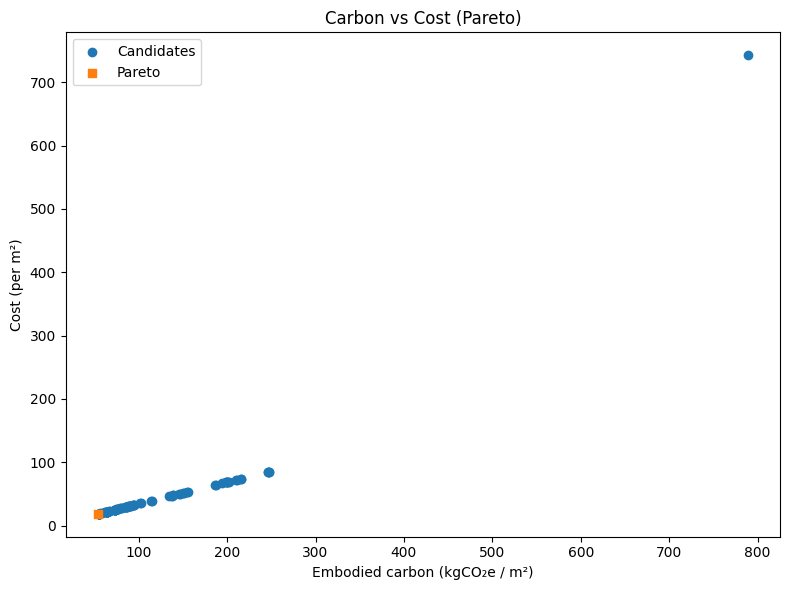

Saved: plots/pareto.png


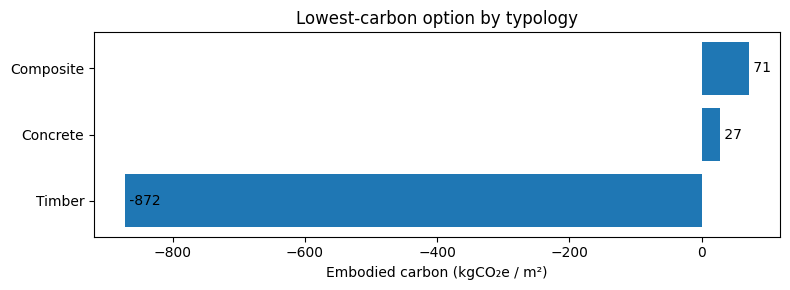

Saved: plots/best_by_typology.png


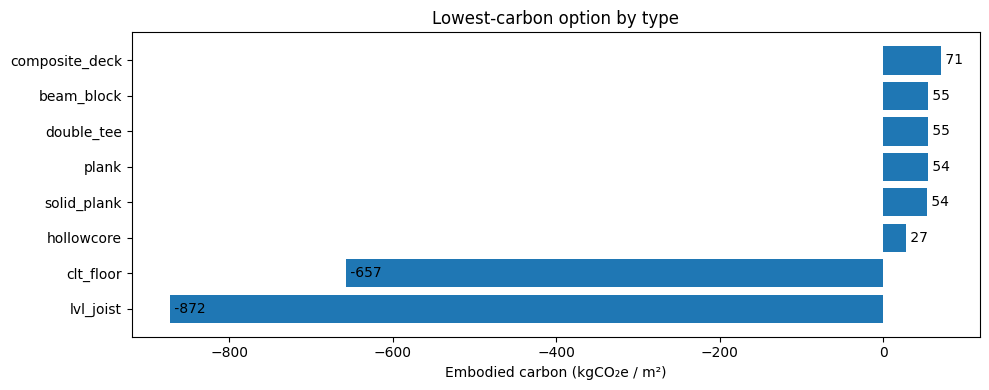

Saved: plots/best_by_type.png


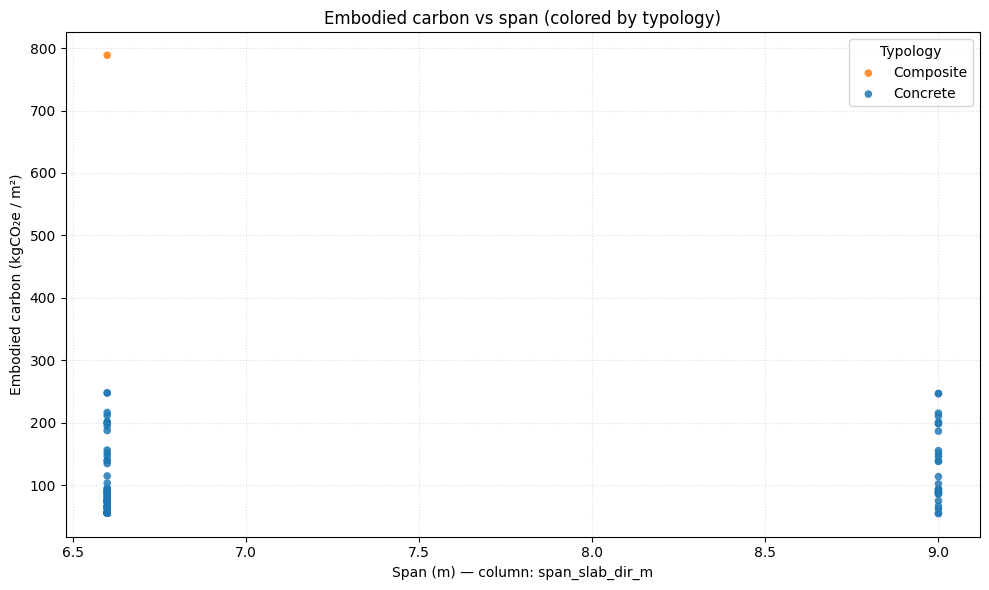

Saved: plots/carbon_vs_span.png


In [5]:
# CELL 4 — minimal reporting + plot saving (no redundant plot cells)

PLOTS_DIR = Path(".") / "plots"
PLOTS_DIR.mkdir(exist_ok=True)

def save_current_fig(path: Path):
    plt.gcf().savefig(path, bbox_inches="tight", dpi=200)
    print("Saved:", path)

# quick summaries (keep the useful ones)
try:
    best_by_type = reporting.cheapest_span_by_type(df_clean)
    display_cols = [c for c in [
        "type", "system_id", "span_slab_dir_m", "span_beam_dir_m", "depth_m",
        "area_m2", "concrete_m3", "steel_m3", "timber_m3",
        "cost_total", "cost_per_m2", "carbon_total_kg", "carbon_per_m2",
    ] if c in best_by_type.columns]
    display(best_by_type[display_cols])
except Exception as e:
    print("⚠️ cheapest_span_by_type failed:", e)

try:
    reporting.print_verbose_summary(df_clean, project, ctl)
except Exception as e:
    print("⚠️ print_verbose_summary failed:", e)

# --- Plots you had that are usually worth keeping ---
try:
    reporting.plot_pareto(df_clean, title="Carbon vs Cost (Pareto)")
    save_current_fig(PLOTS_DIR / "pareto.png")
    plt.close()
except Exception as e:
    print("⚠️ plot_pareto failed:", e)

try:
    reporting.plot_best_typology_carbon(df_clean, title="Lowest-carbon option by typology")
    save_current_fig(PLOTS_DIR / "best_by_typology.png")
    plt.close()
except Exception as e:
    print("⚠️ plot_best_typology_carbon failed:", e)

try:
    reporting.plot_best_type_carbon(df_clean, title="Lowest-carbon option by type")
    save_current_fig(PLOTS_DIR / "best_by_type.png")
    plt.close()
except Exception as e:
    print("⚠️ plot_best_type_carbon failed:", e)

# Optional: carbon vs span scatter (single plot; remove the grid-expansion monster unless you truly need it)
try:
    reporting.plot_carbon_vs_span(
        df_clean,
        span_col="span_slab_dir_m",
        carbon_col="carbon_per_m2",
        min_span=0.0,
        only_feasible=True,
        title="Embodied carbon vs span (colored by typology)",
    )
    save_current_fig(PLOTS_DIR / "carbon_vs_span.png")
    plt.close()
except Exception as e:
    print("⚠️ plot_carbon_vs_span failed:", e)


In [6]:
# CELL 5 — code-check wrapper (single clean version)

from typing import Optional, Union

def sanitize_bar_spacing(df: Optional[pd.DataFrame]) -> Optional[pd.DataFrame]:
    """Return DataFrame with one numeric column 'area' (sorted unique)."""
    if df is None or not isinstance(df, pd.DataFrame) or df.empty:
        return None

    # prefer columns containing 'area'
    candidates = [c for c in df.columns if "area" in c.lower()] + [c for c in df.columns if "area" not in c.lower()]
    for col in candidates:
        ser = pd.to_numeric(df[col], errors="coerce")
        ser = ser[(ser > 0) & ser.notna()]
        if len(ser) > 0:
            arr = np.unique(np.sort(ser.astype(float).values))
            return pd.DataFrame({"area": arr})

    print(f"⚠️ bar_spacing has no usable numeric column. cols={list(df.columns)}")
    return None

def select_system_row(systems_catalog: pd.DataFrame, selector: Optional[Union[str, int]] = None) -> pd.Series:
    """Pick a row by system_id (str) or index (int). Default: first 'concrete' category if present."""
    if selector is None:
        if "category" in systems_catalog.columns:
            mask = systems_catalog["category"].astype(str).str.lower().eq("concrete")
            if mask.any():
                return systems_catalog.loc[mask].iloc[0]
        return systems_catalog.iloc[0]

    if isinstance(selector, int):
        return systems_catalog.iloc[selector]

    # selector is assumed to be system_id
    if "system_id" not in systems_catalog.columns:
        raise KeyError("systems_catalog missing 'system_id'")
    m = systems_catalog["system_id"].astype(str) == str(selector)
    if not m.any():
        raise ValueError(f"system_id not found in systems_catalog: {selector}")
    return systems_catalog.loc[m].iloc[0]

def inject_span_keys(row_dict: dict, span_m: float):
    """Set multiple keys so whatever continuouslab expects will see the span."""
    row_dict["span"] = span_m
    row_dict["length"] = span_m
    row_dict["span_input_m"] = span_m
    row_dict["span_m"] = span_m
    row_dict["span_slab_dir_m"] = span_m

def run_code_check_for_system(
    systems_catalog: pd.DataFrame,
    system_selector: Optional[Union[str, int]] = None,
    bar_spacing_df: Optional[pd.DataFrame] = None,
    program_df: Optional[pd.DataFrame] = None,
    span_override_m: Optional[float] = None,
) -> dict:
    """
    - choose system row
    - apply program overrides (if any)
    - inject span if span_override_m provided
    - sanitize bar spacing
    - call continuouslab_mod.check_slab_row_preserve_math
    - return summary dict
    """
    sel_row = select_system_row(systems_catalog, system_selector)
    row_dict = sel_row.to_dict()

    if program_df is not None and "system_id" in program_df.columns:
        pm = program_df.loc[program_df["system_id"].astype(str) == str(sel_row.get("system_id"))]
        if len(pm) > 0:
            row_dict.update(pm.iloc[0].dropna().to_dict())

    if span_override_m is not None:
        inject_span_keys(row_dict, float(span_override_m))

    bs_clean = sanitize_bar_spacing(bar_spacing_df if bar_spacing_df is not None else getattr(continuouslab_mod, "bar_spacing", None))

    if not hasattr(continuouslab_mod, "check_slab_row_preserve_math"):
        raise AttributeError("continuouslab_mod missing check_slab_row_preserve_math")

    results = continuouslab_mod.check_slab_row_preserve_math(row_dict, bar_spacing_df=bs_clean)

    dims = getattr(continuouslab_mod, "Dimensions", {}) or {}
    span_used = float(
        row_dict.get("span")
        or row_dict.get("max_span")
        or dims.get("base_slab_length")
        or 0.0
    )

    defl = results.get("deflection", {}) or {}
    shear = results.get("shear", {}) or {}
    flex = results.get("flex", {}) or {}

    # checks
    max_span_int = defl.get("max_span_int")
    deflection_ok = False
    try:
        if max_span_int is not None and not (isinstance(max_span_int, float) and np.isnan(max_span_int)):
            deflection_ok = float(max_span_int) >= span_used
    except Exception:
        deflection_ok = False

    V_rdc = shear.get("V_rdc")
    V_ed_ext = shear.get("V_ed_ext")
    shear_ok = True
    if V_rdc is not None and V_ed_ext is not None:
        try:
            shear_ok = float(V_rdc) >= float(V_ed_ext)
        except Exception:
            shear_ok = True

    flex_ok = (flex.get("allowable_ext_reinforcement") is not None) and (flex.get("allowable_int_reinforcement") is not None)

    out = {
        "system_id": sel_row.get("system_id"),
        "pass": bool(deflection_ok and shear_ok and flex_ok),
        "deflection_ok": bool(deflection_ok),
        "shear_ok": bool(shear_ok),
        "flex_ok": bool(flex_ok),
        "reinforcement": {
            "As_req_ext_mm2_per_m": flex.get("required_ext_reinforcement"),
            "As_allowable_ext_mm2": flex.get("allowable_ext_reinforcement"),
            "rho_ext": flex.get("rho_ext"),
            "As_req_int_mm2_per_m": flex.get("required_int_reinforcement"),
            "As_allowable_int_mm2": flex.get("allowable_int_reinforcement"),
            "rho_int": flex.get("rho_int"),
        },
        "diagnostics": {
            "span_used_m": span_used,
            "G_kN_m2": results.get("G_kN_m2"),
            "Q_kN_m2": results.get("Q_kN_m2"),
            "ULS_kN_m2": results.get("ULS_kN_m2"),
            "effective_depth_m": results.get("slab_effective_depth_m"),
            "deflection": defl,
            "shear": shear,
            "flex_details": flex,
            "bar_spacing_used": (bs_clean["area"].head(10).tolist() if bs_clean is not None else None),
        },
    }
    return out

def print_code_check_summary(result: dict):
    if not result:
        print("No result")
        return
    sid = result.get("system_id", "<unknown>")
    ok = result.get("pass", False)
    print(f"=== Eurocode check for {sid} ===")
    print("Overall:", "PASS ✅" if ok else "FAIL ❌")
    print("Checks:")
    print(" - Deflection:", "OK" if result.get("deflection_ok") else "FAIL")
    print(" - Shear:     ", "OK" if result.get("shear_ok") else "FAIL")
    print(" - Flexural:  ", "OK" if result.get("flex_ok") else "FAIL")

    r = result.get("reinforcement", {})
    print("\nReinforcement (mm² per m):")
    print(f" External required: {r.get('As_req_ext_mm2_per_m')}, allowable: {r.get('As_allowable_ext_mm2')}, rho_ext: {r.get('rho_ext')}")
    print(f" Internal required: {r.get('As_req_int_mm2_per_m')}, allowable: {r.get('As_allowable_int_mm2')}, rho_int: {r.get('rho_int')}")

    d = result.get("diagnostics", {})
    print("\nKey diagnostics:")
    print(f" span_used_m={d.get('span_used_m')}")
    print(f" G={d.get('G_kN_m2')}, Q={d.get('Q_kN_m2')}, ULS={d.get('ULS_kN_m2')}")
    print(f" effective_depth_m={d.get('effective_depth_m')}")
    sh = d.get("shear", {}) or {}
    if sh:
        print(f" V_rdc={sh.get('V_rdc')}, V_ed_ext={sh.get('V_ed_ext')}, V_rdcmin={sh.get('V_rdcmin')}")
    print("=====================")

print("✅ Wrapper ready")


✅ Wrapper ready


In [7]:
# CELL 6 — pick a top system_id + run check using the optimizer span (no undefined vars)

systems_catalog = pd.read_csv(DATA_DIR / "systems_catalog.csv")

# choose a preferred system_id from ranked (feasible first)
chosen_system_id = None
chosen_span_m = None

if isinstance(ranked, pd.DataFrame) and not ranked.empty:
    r2 = ranked.copy()
    if "feasible" in r2.columns:
        r2["feasible"] = normalize_feasible(r2["feasible"])
        r2_feas = r2[r2["feasible"]]
        chosen_row = r2_feas.iloc[0] if not r2_feas.empty else r2.iloc[0]
    else:
        chosen_row = r2.iloc[0]

    chosen_system_id = chosen_row.get("system_id")
    # prefer the slab direction span if present
    for cand in ("span_slab_dir_m", "span_input_m", "span_m", "span_beam_dir_m"):
        if cand in chosen_row and pd.notna(chosen_row[cand]):
            chosen_span_m = float(chosen_row[cand])
            break

print("Chosen system_id:", chosen_system_id)
print("Chosen span (m):", chosen_span_m)

# run check
program_df = saved.get("program") if isinstance(saved, dict) else None
result = run_code_check_for_system(
    systems_catalog=systems_catalog,
    system_selector=chosen_system_id,
    bar_spacing_df=bar_spacing_raw,
    program_df=program_df,
    span_override_m=chosen_span_m,   # can be None; wrapper handles it
)

print_code_check_summary(result)


Chosen system_id: flood_super_voidslab
Chosen span (m): 9.0
ULS combinations: 9.675, 9.675, 9.125
sigma_d_ext, F3_ext: 286395.27247227373 1.0824201018542003
sigma_d_int, F3_int: 270110.1838855058 1.147679793263192
allowable_ext_reinforcement: 0.0007634
=== Eurocode check for flood_super_voidslab ===
Overall: PASS ✅
Checks:
 - Deflection: OK
 - Shear:      OK
 - Flexural:   OK

Reinforcement (mm² per m):
 External required: 0.0007571049556872377, allowable: 0.0007634, rho_ext: 0.003457100254279624
 Internal required: 0.0005546233977708835, allowable: 0.0005655, rho_int: 0.002532526930460655

Key diagnostics:
 span_used_m=9.0
 G=5.5, Q=1.5, ULS=9.675
 effective_depth_m=0.219
 V_rdc=58.331580617963105, V_ed_ext=32.614425000000004, V_rdcmin=114.81672182388368
